In [49]:
import pandas as pd
import seaborn as sns


In [73]:
df = pd.read_csv('https://raw.githubusercontent.com/ClaudiaSobral/treinamento-dados-end-to-end/refs/heads/main/data/golden/imdb_movies_tratado.csv')

In [74]:
df['status'] = df['status'].str.strip()

In [75]:
df = df[df['status'] == 'Released']

In [76]:
linhas = df.shape[0]

print(f"O dataset contém {linhas} registros.")

O dataset contém 6115 registros.


In [77]:
df.head()

,names,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,data_editada,data,elenco_lista,estrelas,margem_de_lucro,roi
0,Creed III,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,03/02/2023,2023-03-02,"['Michael B. Jordan', 'Adonis Creed', 'Tessa T...",4,72.387556,3.621556
1,Avatar: The Way of Water,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,12/15/2022,2022-12-15,"['Sam Worthington', 'Jake Sully', 'Zoe Saldaña...",4,80.144984,5.036511
2,The Super Mario Bros. Movie,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,04/05/2023,2023-04-05,"['Chris Pratt', 'Mario (voice)', 'Anya Taylor-...",4,86.196597,7.244590
3,Mummies,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,01/05/2023,2023-01-05,"['Óscar Barberán', 'Thut (voice)', 'Ana Esther...",4,64.035088,2.780488
4,Supercell,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,03/17/2023,2023-03-17,"['Skeet Ulrich', 'Roy Cameron', 'Anne Heche', ...",4,77.415511,4.427818


In [78]:
df['data'].min()

'2009-01-01'

In [55]:
df.isnull().sum()

names              0
score              0
genre              0
overview           0
crew               0
orig_title         0
status             0
orig_lang          0
budget_x           0
revenue            0
country            0
data_editada       0
data               0
elenco_lista       0
estrelas           0
margem_de_lucro    0
roi                0
dtype: int64

In [56]:
df_numerico = df.select_dtypes(exclude=['object'])
matriz_correlacao = df_numerico.corr()

matriz_correlacao

,score,budget_x,revenue,estrelas,margem_de_lucro,roi
score,1.000000,-0.168704,0.141924,0.904130,0.020034,0.005635
budget_x,-0.168704,1.000000,0.665917,-0.142261,0.016941,-0.016534
revenue,0.141924,0.665917,1.000000,0.122779,0.015300,-0.001672
estrelas,0.904130,-0.142261,0.122779,1.000000,0.012707,0.006855
margem_de_lucro,0.020034,0.016941,0.015300,0.012707,1.000000,0.000202
roi,0.005635,-0.016534,-0.001672,0.006855,0.000202,1.000000


<Axes: >

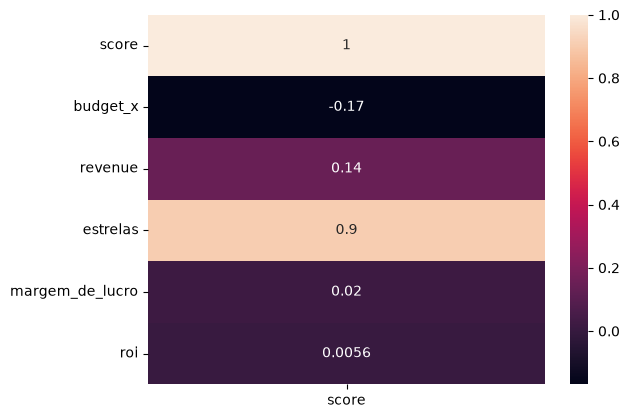

In [57]:
sns.heatmap(matriz_correlacao[['score']], annot=True)

<Axes: >

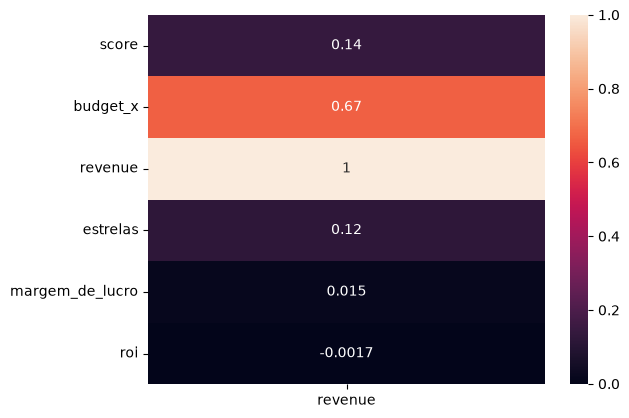

In [58]:
sns.heatmap(matriz_correlacao[['revenue']], annot=True)

<Axes: >

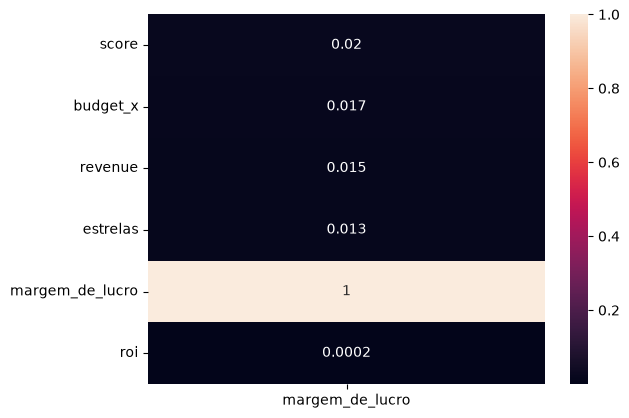

In [59]:
sns.heatmap(matriz_correlacao[['margem_de_lucro']], annot=True)

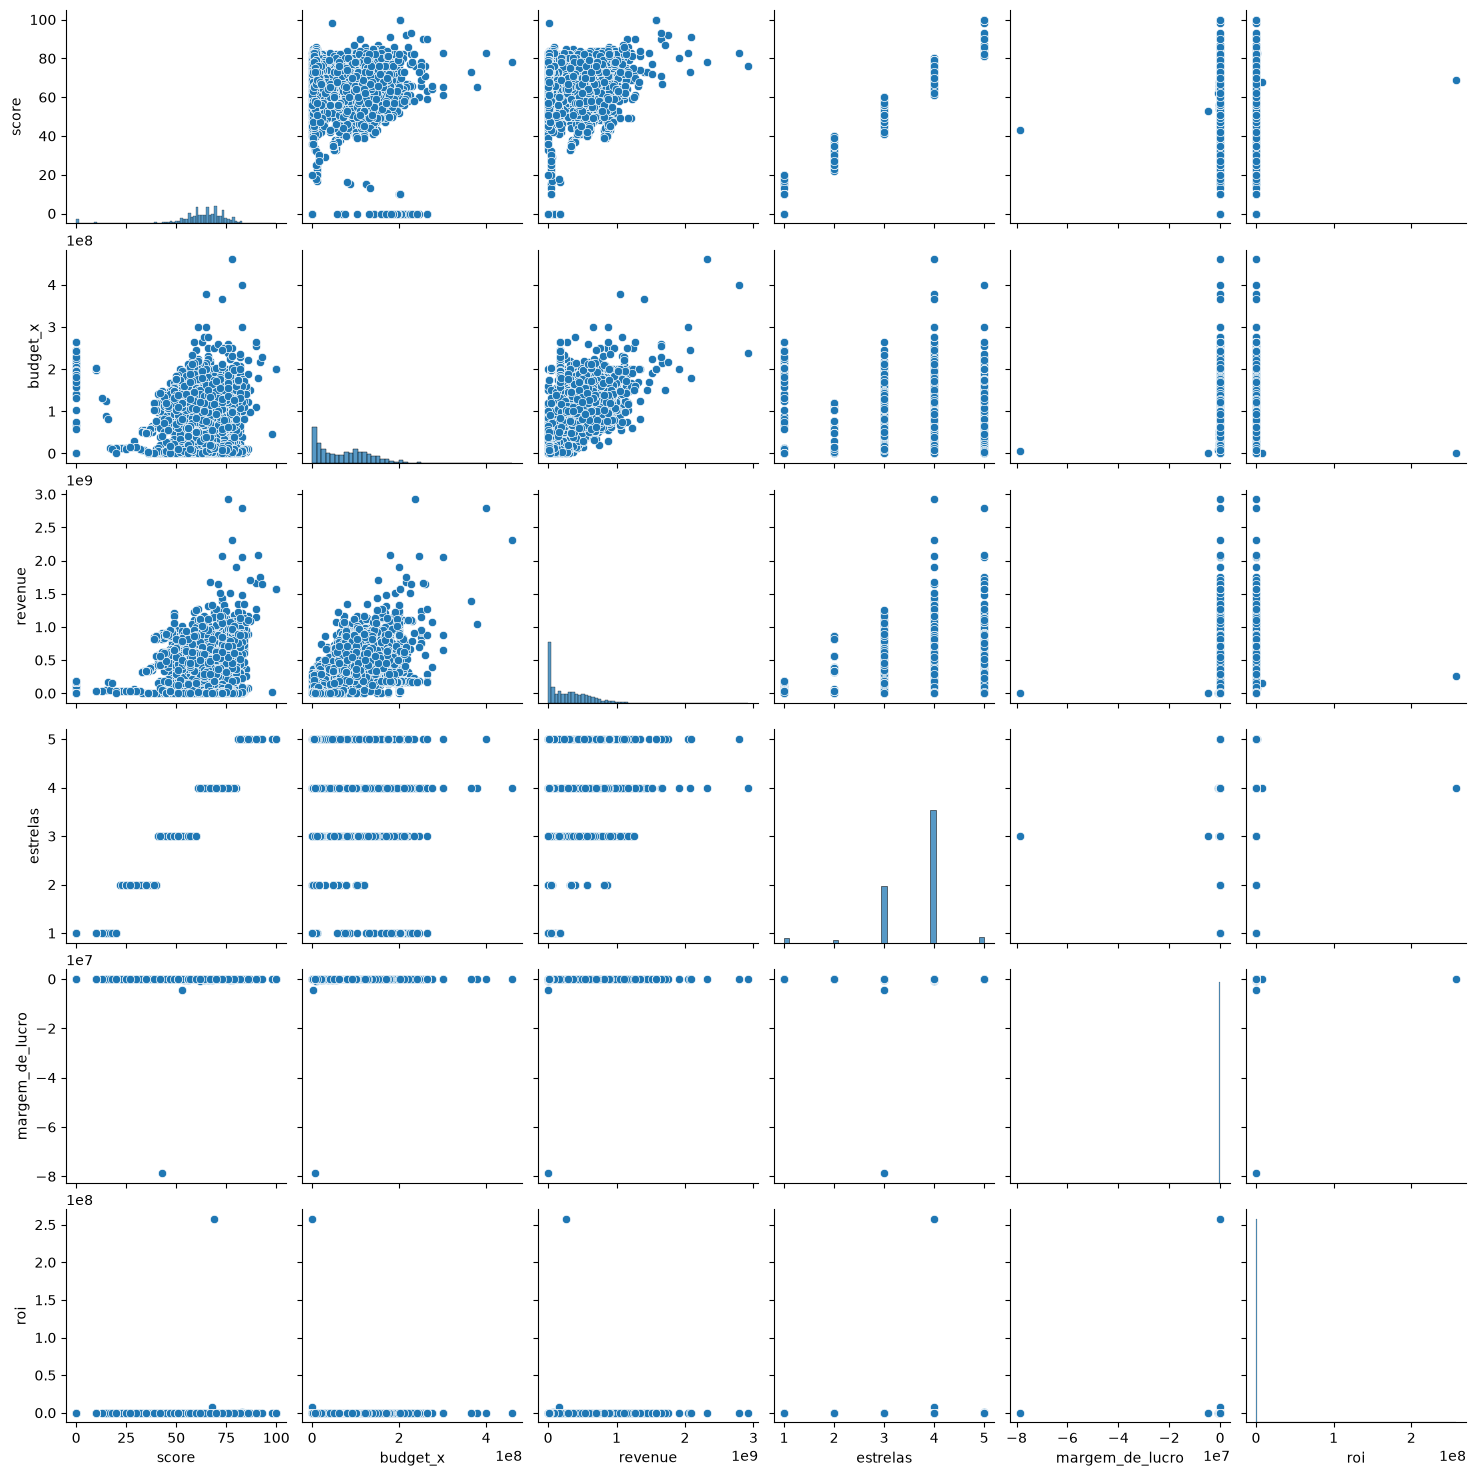

In [60]:
sns.pairplot(df)

In [61]:
df.shape[0]

6115

In [62]:
from scipy import stats
import pandas as pd

# Calculate Z-scores for a specific column
df['z_score'] = stats.zscore(df['revenue'])

# Identify outliers
outliers = abs(df['z_score']) > 3
outliers

df_sem_outliers = df[~outliers]
df_sem_outliers.shape[0]

6066

In [63]:
df_documentario = df[df['genre'].str.contains("Documentary")]
df_documentario.sort_values(by='revenue', ascending=False)



,names,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,data_editada,data,elenco_lista,estrelas,margem_de_lucro,roi,z_score
3078,Louis Tomlinson: All of Those Voices,91.0,"Documentary, Music",Ditching the typical glossy sheen of celebrity...,"Louis Tomlinson, Self, Oliver Wright, Louis’ P...",Louis Tomlinson: All of Those Voices,Released,English,178800000.0,2.081794e+09,GB,03/22/2023,2023-03-22,"['Louis Tomlinson', 'Self', 'Oliver Wright', '...",5,91.411254,11.643143,6.144937
1637,BTS: Permission to Dance on Stage - LA,92.0,"Music, Documentary","Purple colors the city of Los Angeles, as BTS ...","Kim Nam-joon, Self, Kim Seok-jin, Self, Min Yo...",BTS: PERMISSION TO DANCE 온 스테이지 – LA,Released,Korean,215600000.0,1.748017e+09,KR,09/08/2022,2022-09-08,"['Kim Nam-joon', 'Self', 'Kim Seok-jin', 'Self...",5,87.666027,8.107688,4.999660
3242,Directing Annabelle: Creation,93.0,Documentary,Director David F. Sandberg takes you through t...,"David F. Sandberg, Himself, Talitha Bateman, H...",Directing Annabelle: Creation,Released,English,227800000.0,1.644265e+09,US,08/07/2017,2017-08-07,"['David F. Sandberg', 'Himself', 'Talitha Bate...",5,86.145787,7.218021,4.643658
5836,Charlton Heston: Radical to Right Wing,90.0,"Documentary, TV Movie",A look at the life and work of the iconic US a...,"Maud Guillaumin, Self - Narrator (voice), Jona...",Charlton Heston : la démesure d'un géant,Released,French,264000000.0,1.263824e+09,FR,02/24/2023,2023-02-24,"['Maud Guillaumin', 'Self - Narrator (voice)',...",5,79.111017,4.787213,3.338262
6060,Folklore: The Long Pond Studio Sessions,86.0,"Music, Documentary","An intimate concert film, in which Taylor Swif...","Taylor Swift, Self, Jack Antonoff, Self, Aaron...",Folklore: The Long Pond Studio Sessions,Released,English,221000000.0,1.104642e+09,US,11/25/2020,2020-11-25,"['Taylor Swift', 'Self', 'Jack Antonoff', 'Sel...",5,79.993520,4.998381,2.792065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5108,Pope Francis: A Man of His Word,73.0,Documentary,Pope Francis responds to questions from around...,"Pope Francis, Self, Ignazio Oliva, Francesco d...",Pope Francis: A Man of His Word,Released,English,3398000.0,2.423465e+06,US,05/18/2018,2018-05-18,"['Pope Francis', 'Self', 'Ignazio Oliva', ""Fra...",4,-40.212464,0.713203,-0.989945
5590,Blackfish,79.0,Documentary,Notorious killer whale Tilikum is responsible ...,"Dean Gomersall, Self, Samantha Berg, Self, Joh...",Blackfish,Released,English,29551333.2,2.063312e+06,AU,06/07/2013,2013-06-07,"['Dean Gomersall', 'Self', 'Samantha Berg', 'S...",4,-1332.228049,0.069821,-0.991180
5408,77+33=?,0.0,"Documentary, Mystery, Adventure",Test the average IQ of Vietnamese people with ...,"Minh Tu Le, Bạn, Nguyễn Phan Thái Vũ, Tôi, Hải...",77+33=?,Released,Vietnamese,22.0,1.232396e+06,VN,04/07/2023,2023-04-07,"['Minh Tu Le', 'Bạn', 'Nguyễn Phan Thái Vũ', '...",1,99.998215,56018.009091,-0.994031
4159,Fantastic Fungi,73.0,Documentary,A vivid journey into the mysterious subterrane...,"Brie Larson, Narrator (voice), Paul Stamets, H...",Fantastic Fungi,Released,English,3398000.0,1.096179e+06,US,08/30/2019,2019-08-30,"['Brie Larson', 'Narrator (voice)', 'Paul Stam...",4,-209.985869,0.322595,-0.994499


In [64]:
df['crew']

0       Michael B. Jordan, Adonis Creed, Tessa Thompso...
1       Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...
2       Chris Pratt, Mario (voice), Anya Taylor-Joy, P...
3       Óscar Barberán, Thut (voice), Ana Esther Albor...
4       Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...
                              ...                        
6155    Cate Blanchett, Bernadette, Billy Crudup, Elgi...
6156    Chadwick Boseman, Thurgood Marshall, Josh Gad,...
6157    Yuki Kaji, Meliodas (voice), Sora Amamiya, Eli...
6158    Annette Bening, Dorothea Fields, Lucas Jade Zu...
6159    Nina Herzog, Princess Odette (voice), Yuri Low...
Name: crew, Length: 6115, dtype: str

In [65]:
generos_unicos = sorted(list({g.strip() for item in df['genre'].dropna() for g in item.split(',')}))

print(generos_unicos)

['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [66]:
linguas_unicas = sorted(list({l.strip() for item in df['orig_lang'].dropna() for l in item.split(',')}))

print(linguas_unicas)

['Arabic', 'Basque', 'Bengali', 'Bokmål', 'Cantonese', 'Castilian', 'Catalan', 'Central Khmer', 'Chinese', 'Czech', 'Danish', 'Dutch', 'Dzongkha', 'English', 'Finnish', 'Flemish', 'French', 'Galician', 'German', 'Greek', 'Gujarati', 'Hindi', 'Hungarian', 'Icelandic', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Kannada', 'Korean', 'Latin', 'Latvian', 'Macedonian', 'Malay', 'Malayalam', 'No Language', 'Norwegian', 'Norwegian Bokmål', 'Oriya', 'Persian', 'Polish', 'Portuguese', 'Romanian', 'Russian', 'Serbian', 'Slovak', 'Spanish', 'Swedish', 'Tagalog', 'Tamil', 'Telugu', 'Thai', 'Turkish', 'Ukrainian', 'Valencian', 'Vietnamese']


In [67]:
resumo = []
for g in generos_unicos:
    filtro = df[df['genre'].str.contains(g, na=False)]
    resumo.append({
        'Gênero': g,
        'Qtd Filmes': len(filtro),
        'Nota Mediana': filtro['score'].median(),
        'Orçamento Mediana': filtro['revenue'].median(),
        'Lucro Mediana': filtro['budget_x'].median(),
        'ROI Mediana': filtro['roi'].median()
    })

df_resumo = pd.DataFrame(resumo)
display(df_resumo.sort_values(by='Nota Mediana', ascending=False))

,Gênero,Qtd Filmes,Nota Mediana,Orçamento Mediana,Lucro Mediana,ROI Mediana
11,Music,176,71.0,319623657.7,74800000.0,4.139564
5,Documentary,172,70.0,560963629.4,90100000.0,6.087397
2,Animation,959,70.0,397948698.4,97200000.0,4.179791
9,History,248,70.0,72188697.5,41500000.0,2.577188
17,War,146,69.5,96417227.0,41280560.0,2.928044
7,Family,817,68.0,353166307.0,93000000.0,3.685996
1,Adventure,1035,67.0,276620676.6,90000000.0,3.177975
8,Fantasy,823,67.0,294763505.4,88200000.0,3.400085
6,Drama,2236,67.0,147669851.5,50000000.0,3.279390
18,Western,50,66.0,154913595.1,55000000.0,2.063870


In [68]:
resumo_linguas = []
for l in linguas_unicas:
    filtro = df[df['orig_lang'].str.contains(l, na=False)]
    resumo_linguas.append({
        'Língua falada': l,
        'Qtd filmes': len(filtro),
        'Nota média': filtro['score'].median(),
        'Orçamento médio': filtro['revenue'].median(),
        'Lucro médio': filtro['budget_x'].median(),
        'ROI médio': filtro['roi'].median()
    })

df_resumo_linguas = pd.DataFrame(resumo_linguas)
display(df_resumo_linguas[df_resumo_linguas['Qtd filmes'] > 10].sort_values(by='Nota média', ascending=False))

,Língua falada,Qtd filmes,Nota média,Orçamento médio,Lucro médio,ROI médio
27,Japanese,402,71.0,422349665.6,99030000.0,4.099491
10,Danish,20,69.5,103275302.0,18600000.0,3.024409
8,Chinese,119,68.0,254212245.0,65000000.0,4.308200
24,Indonesian,11,68.0,339023160.4,83600000.0,4.086996
21,Hindi,20,67.5,318336808.0,65600000.0,4.365722
36,Norwegian,29,67.0,116911978.0,16600000.0,2.920064
5,Castilian,322,66.5,369861963.8,88600000.0,4.621759
18,German,48,66.5,194200616.3,55450000.0,4.359891
46,Spanish,322,66.5,369861963.8,88600000.0,4.621759
4,Cantonese,27,66.0,176345966.0,38272500.0,3.391269


In [69]:
# 1. Explode da coluna de elenco/atores
df_atores = df.dropna(subset=['elenco_lista', 'score']).copy()
df_atores = df_atores.assign(ator=df_atores['elenco_lista'].str.split(',')).explode('ator')

# Limpa os espaços e remove a marcação " (voice)" de forma insensível a maiúsculas/minúsculas
df_atores['ator'] = (
    df_atores['ator']
    .str.strip()
    .str.replace(r'\s*\([vV]oice\)', '', regex=True)
)

# Opcional: Remove linhas que eventualmente tenham ficado vazias após o tratamento
df_atores = df_atores[df_atores['ator'] != '']

# 2. Métrica de Consistência por Ator (mínimo de 4 filmes)
estatisticas_atores = df_atores.groupby('ator').agg(
    qtd_filmes=('names', 'count'),
    nota_media=('score', 'mean'),
    nota_mediana=('score', 'median'),
    desvio_padrao=('score', 'std') # Medida de consistência/risco
).query('qtd_filmes >= 10').sort_values(by='nota_media', ascending=False)

display(estatisticas_atores.head(15))

,qtd_filmes,nota_media,nota_mediana,desvio_padrao
ator,,,,
'Inori Minase',10,77.800000,79.0,5.094660
'Daphne Blake',20,77.250000,78.0,3.176807
'Mindy Cohn',14,76.214286,78.0,6.015091
'Maaya Uchida',12,75.750000,77.0,6.648650
'Velma Dinkley',22,75.727273,78.0,7.541516
'Shaggy Rogers',22,75.636364,78.0,7.512183
'Scooby-Doo / Fred Jones',14,75.571429,78.0,9.120681
'Clark Kent / Superman',10,75.300000,74.5,4.620005
'Yuriko Yamaguchi',10,75.200000,75.0,4.022161


In [70]:
# Identificando sequências prováveis
df['eh_sequencia'] = df['names'].str.contains(r'\b(2|3|4|II|III|Part|Sequel)\b', regex=True, na=False)

# Comparando notas
df.groupby('eh_sequencia')['score'].agg(['count', 'mean', 'median', 'std'])

C:\Users\claud\AppData\Local\Temp\ipykernel_19472\540430922.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['eh_sequencia'] = df['names'].str.contains(r'\b(2|3|4|II|III|Part|Sequel)\b', regex=True, na=False)


,count,mean,median,std
eh_sequencia,,,,
False,5754,63.425269,65.0,13.140950
True,361,61.243767,64.0,16.171696


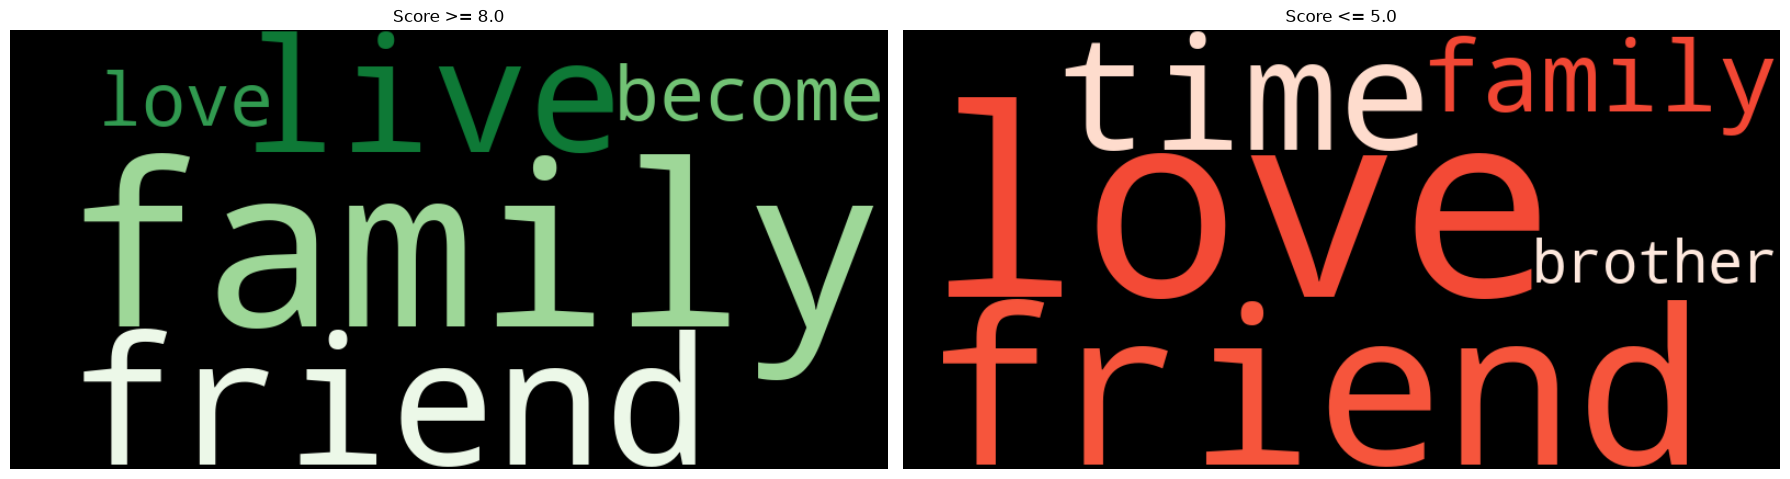

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

# Lista manual de stopwords comuns em inglês (dispensa o NLTK)
stopwords_ingles = {
    'a', 'about', 'above', 'adding', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'aren\'t', 'as', 'at',
    'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'cannot', 'could', 'database',
    'did', 'do', 'does', 'doing', 'don\'t', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'get', 'goes', 'had', 'has',
    'have', 'having', 'he', 'her', 'here', 'hers', 'him', 'himself', 'his', 'how', 'i', 'if', 'in', 'into', 'is',
    'it', 'its', 'itself', 'just', 'like', 'me', 'more', 'most', 'my', 'myself', 'no', 'nor', 'not', 'of', 'off', 'on', 'once',
    'only', 'or', 'other', 'our', 'ours', 'out', 'over', 'overview', 'own', 'same', 'she', 'should', 'so', 'some', 'such', 'than',
    'that', 'the', 'their', 'theirs', 'them', 'themselves', 'then', 'there', 'these', 'they', 'this', 'those', 'through', 'translated',
    'to', 'too', 'under', 'until', 'up', 'us', 'very', 'we', 'was', 'were', 'will', 'what', 'when', 'where', 'which', 'while', 'who', 'whom',
    'why', 'with', 'would', 'you', 'your', 'yours', 'yourself', 'yourselves', 's', 'expand', 'english', 'help', 'day', 'gets', 'however', 'become'
    # Palavras genéricas de cinema
    'movie', 'film', 'life', 'story', 'one', 'two', 'find', 'finds', 'man', 'woman', 'young', 'new', 'world', 'take', 'takes'
}

# Filtrar resumos
top_scores = df[df['score'] >= 8.0]['overview'].dropna()
low_scores = df[df['score'] <= 5.0]['overview'].dropna()

texto_top = " ".join(top_scores)
texto_low = " ".join(low_scores)

# Gerar WordClouds
wc_top = WordCloud(width=800, height=400, background_color='black', colormap='Greens', stopwords=stopwords_ingles, max_words=5).generate(texto_top)
wc_low = WordCloud(width=800, height=400, background_color='black', colormap='Reds', stopwords=stopwords_ingles, max_words=5).generate(texto_low)

# Plotar
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(wc_top, interpolation='bilinear')
axes[0].set_title('Score >= 8.0')
axes[0].axis('off')

axes[1].imshow(wc_low, interpolation='bilinear')
axes[1].set_title('Score <= 5.0')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [72]:
df[df['overview'].str.contains('expand')]

,names,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,data_editada,data,elenco_lista,estrelas,margem_de_lucro,roi,z_score,eh_sequencia
190,Malcriados,78.0,Comedy,We don't have an overview translated in Englis...,"Renata Notni, , Cassandra Sánchez Navarro, , C...",Malcriados,Released,"Spanish, Castilian",116600000.0,5.869075e+08,MX,02/15/2023,2023-02-15,"['Renata Notni', '', 'Cassandra Sánchez Navarr...",4,80.133154,5.033512,1.015578,False
248,El tirabeque,30.0,Comedy,We don't have an overview translated in Englis...,"Darío Autrán, , Déborah Vukusic, , Lidia Veiga...",El tirabeque,Released,"Spanish, Castilian",15541000.0,3.813901e+07,ES,11/25/2022,2022-11-25,"['Darío Autrán', '', 'Déborah Vukusic', '', 'L...",2,59.251695,2.454090,-0.867395,False
401,El asistente,100.0,Comedy,We don't have an overview translated in Englis...,"Rodrigo Noya, Miguel, Luis Cao, Jimmy, Florenc...",El asistente,Released,"Spanish, Castilian",201000000.0,1.569324e+09,AR,03/01/2023,2023-03-01,"['Rodrigo Noya', 'Miguel', 'Luis Cao', 'Jimmy'...",5,87.191936,7.807581,4.386514,False
625,Golden Escape,67.0,"Drama, Crime",We don't have an overview translated in Englis...,"Justin Cheung, , Ray Lui, , Ricky Chan Po-Yuen...",黄金大逃狱,Released,Chinese,84800000.0,3.536501e+08,CN,08/05/2022,2022-08-05,"['Justin Cheung', '', 'Ray Lui', '', 'Ricky Ch...",4,76.021495,4.170402,0.215209,False
779,Fantastic Beasts and Where to Find Them,73.0,"Adventure, Fantasy, Family","In 1926, Newt Scamander arrives at the Magical...","Eddie Redmayne, Newt Scamander, Katherine Wate...",Fantastic Beasts and Where to Find Them,Released,English,180000000.0,8.117244e+08,AU,11/17/2016,2016-11-17,"['Eddie Redmayne', 'Newt Scamander', 'Katherin...",4,77.824986,4.509580,1.786985,False
840,Jesús de Nazaret: El Hijo de Dios,68.0,"Drama, History",We don't have an overview translated in Englis...,"Julián Gil, , Gaby Espino, , Sergio Marone, , ...",Jesús de Nazaret: El Hijo de Dios,Released,"Spanish, Castilian",103800000.0,2.516786e+08,ES,04/18/2019,2019-04-18,"['Julián Gil', '', 'Gaby Espino', '', 'Sergio ...",4,58.756928,2.424650,-0.134683,False
974,La espina de Dios,50.0,Drama,We don't have an overview translated in Englis...,"Jacinto Montes de Oca, , María Garralón, , Fed...",La espina de Dios,Released,"Spanish, Castilian",151600000.0,6.651945e+08,ES,03/27/2015,2015-03-27,"['Jacinto Montes de Oca', '', 'María Garralón'...",3,77.209672,4.387826,1.284202,False
1046,Adanis: Kutsal Kavga,51.0,"Drama, Action, Adventure",We don't have an overview translated in Englis...,"Esra Bilgiç, Cemre, İsmail Filiz, İlhan, Baki ...",Adanis: Kutsal Kavga,Released,Turkish,3740000.0,5.688280e+05,TR,03/11/2022,2022-03-11,"['Esra Bilgiç', 'Cemre', 'İsmail Filiz', 'İlha...",3,-557.492247,0.152093,-0.996308,False
1309,The Wandering Earth,65.0,"Science Fiction, Action, Drama",When the Sun begins to expand in such a way th...,"Qu Chuxiao, Liu Qi (刘启), Li Guangjie, Wang Lei...",流浪地球,Released,Chinese,48000000.0,2.877165e+08,AU,02/08/2019,2019-02-08,"['Qu Chuxiao', 'Liu Qi (刘启)', 'Li Guangjie', '...",4,83.316911,5.994094,-0.011027,False
1398,Valerian and the City of a Thousand Planets,66.0,"Adventure, Science Fiction, Action","In the 28th century, Valerian and Laureline ar...","Dane DeHaan, Valerian, Cara Delevingne, Laurel...",Valerian and the City of a Thousand Planets,Released,English,180000000.0,2.150984e+08,AU,08/10/2017,2017-08-10,"['Dane DeHaan', 'Valerian', 'Cara Delevingne',...",4,16.317352,1.194991,-0.260200,False
